In [3]:
# so today multi index object very important 
# we learn 4 functions stack ,unstack ,pivot table and melt


# Revise Series and Df

In [4]:
# series is a 1d array object
# index value 
#  -      - 
#  -      - 
#  -      - 


In [5]:
# example
# name  weight 
# nitish 20
# ankit 80
# rahul 90 

In [6]:
# can you prove that series is one dimesion object
# yes agar apko koi series ma sa koi item fetch karna tho aap kasa karoga
# aap us item ka index pata honda chaya
# variable[index] = item
# Dataframe ma apko fetch karna ka liya two information dena hoga 
# example 100 fetch karna ha tho appko
# name and weight dono provide karna hoga
# variable[row_index, coloumn_index ]
# so it proof dataframe is a 2d structure . 


In [7]:
# Datafram is a 2d array object table matrix
#           rows -------------
# coloumns 
# |
# |
# |
# |
# |
# |


In [8]:
# example
# name    weight  height
# nitish   70       160
# ankit    100      158
# rahul    80       165

In [9]:
import numpy as np
import pandas as pd 

# create muldim index in Series 

In [10]:
# can we have multiple index? Let's try
# so I will provide list of tuples to the index value
# in tuple we have first branch name than year 
index_values = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
students = pd.Series([1,2,3,4,5,6,7,8],index=index_values)
students

(cse, 2019)    1
(cse, 2020)    2
(cse, 2021)    3
(cse, 2022)    4
(ece, 2019)    5
(ece, 2020)    6
(ece, 2021)    7
(ece, 2022)    8
dtype: int64

### our goal 

In [11]:
# we want to make like that
#    index              value/item
# branch   year ->  number of students
# cse      2019 ->       120
# ece      2020 ->       160
# .....

### fetch item from it

In [12]:
# we want to fetch 4  
# provide the tuple in the list 
students[('cse',2022)]

4

In [ ]:
# can I fetch all cse students lets try it
students['cse'] 
# cse name ko koi key nahi ha 
# matlab cse name ko index nahi aor sahi bhat ha
# hamra paas ek bhi index asa nahi ha jo kahli cse ho
# cse ka sath kuch tho laga hua . ha 

KeyError: 'cse'

In [ ]:
# so what is the solutioon 

## Create multiindex object 
pandas ma multi-index series ko hi Hierarhical indexing bolta ha (matlab parent uska child uska child and so on ... )

## multiindex from tuples

In [ ]:
import pandas as pd

In [4]:
index_values = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multi_index = pd.MultiIndex.from_tuples(index_values)
multi_index
# multi index object jo ha vo decouple kar deta ha 
# yani branch and year ho alag tara sa treat kara ga 


MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [ ]:
multi_index.levels
# deko usna branch or year ko frozenlist ma kar diya


FrozenList([['cse', 'ece'], [2019, 2020, 2021, 2022]])

In [ ]:
multi_index.levels[0]

Index(['cse', 'ece'], dtype='object')

In [ ]:
multi_index.levels[1]

Index([2019, 2020, 2021, 2022], dtype='int64')

## multi index from product

In [ ]:
# provide a nested 2d list 
pd.MultiIndex.from_product([['cse', 'ece'],[2019, 2020, 2021, 2022]])
# isna set_a and set_b ka bitch ma caretasian product kar diya 

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

## multi index series 
it is also like `tree struture` hierectial struture

```mermaid
flowchart TB
  node_1["cse"]
  node_2["2019"]
  node_3["2020"]
  node_4["2021"]
  node_5["\2022"]
  node_6["ece"]
  node_7["2019"]
  node_8["2020"]
  node_9["2021"]
  node_10["2022"]
  node_1 --> node_2
  node_1 --> node_3
  node_1 --> node_4
  node_1 --> node_5
  node_6 --> node_7
  node_6 --> node_8
  node_6 --> node_9
  node_6 --> node_10
```

In [ ]:
pd.Series([1,2,3,4,5,6,7,8],index=multi_index)

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

## benefit of multi indexing
aap kisi bhi tara sa rows ko fetch kar sakta ho data ko nikal sakta ho 

In [17]:
students = pd.Series([1,2,3,4,5,6,7,8],index=multi_index)
students['cse',2022]

4

In [18]:
# rows nikalho jinma cse ha
students['cse']
# upar jo hamna galat tarika sa banya tha usma aap ya cheez nahi kar sakta

2019    1
2020    2
2021    3
2022    4
dtype: int64

## dimension of multi index series 
ya jo hamna multiindex series banya ha iska dimesnion kiya ha 

In [ ]:
# muja ko nikalna ha tho kitna index provide karna padega
# first branch dursa year 
# tho multidim series 2 dimesnion 
# logical question hum 2 dim ma series kyu karaga hum tho essa dataframe ma convert karga ga
# you are right

# stack and unstack in series 

## unstack 
convert multi-index series to dataframe

In [21]:
students

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [ ]:
students.unstack()

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [ ]:
# abhi bhi aap same information represent kar raho ho 
# level0 index to rows level 1 to coloumns ma 

## stack 
convert dataframe to multi index series 

In [ ]:
students_df = students.unstack()
students_df

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [ ]:
students_df.stack()


cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [ ]:
# wow we convert again into multi-index series 


In [ ]:
# why should we convert into multi index object if we have the dataframe
# answer 
# apna ek higher dimesion data ko lower dimension data ma represent kiya 
# dataframe 2d or usko apna 1d multi index series ma represent kiya
# what happen if we extend this idea 
# tho aap 3dimension data ko 2d dataframe ma represent karo
#  4 dim data ko 2dim dataframe ma represent karo
#  or ya 10 dim data ko 2dim dataframe ma represent karo

# why study multi index 
aap kisi bhi higher dimension data exmaple 10dim ,50 dim ko lower dimension series(1d) ya dataframe(2d) ma represent kar sakta ho 
`This is true power of pandas `

# multi index dataframe 

In [ ]:
# multi index dataframe


#             avg_package no_of_students
# branch year 

# koi ek values nikalna ka liya apko 3 information chaya
# row index  1.(branch,year)
# col index  2.avg_package  3.no_of_students

In [ ]:
# passing a nested 2d list ,passes multiindex and col name 

## multi index df row 

In [2]:
import pandas as pd 

In [5]:
branch_df1 = pd.DataFrame(
    [
        [1,2],
        [3,4],
        [5,6],
        [7,8],
        [9,10],
        [11,12],
        [13,14],
        [15,16],
    ],
    index = multi_index,
    columns = ['avg_package','students']
)

branch_df1

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [ ]:
# shape 8 rows 2 coloumns 

In [ ]:
branch_df1.loc['ece']

,avg_package,students
2019,9,10
2020,11,12
2021,13,14
2022,15,16


In [ ]:
branch_df1['avg_package']
# it returen multi index series
branch_df1['students']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

In [ ]:
# deep impleneation level pandas index k
# index  column ko same cheeza samjta ha 
# matlab abhi tak humna hierachy index rows ma kari ha hum chaya tho 
# coloumns bhi kar sakta ha 

## multi index df col

In [ ]:
# ab apko isma bhi 2 information chaya ek item ko nikalna ka liya
# 1. konsa saal ma ha year
# 2.konsa city ma ha  , kiya  package laga
# 3.konsa city ma ha  , kitna student tha
# so ya ha 3 dimension data 

In [6]:
branch_df2 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
    ],
    index = [2019,2020,2021,2022],
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

branch_df2

delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [ ]:
branch_df2['delhi']

,avg_package,students
2019,1,2
2020,3,4
2021,5,6
2022,7,8


In [ ]:
# example apko mumbai ka avg package nikana ha 
branch_df2['mumbai']['avg_package']

2019    0
2020    0
2021    0
2022    0
Name: avg_package, dtype: int64

In [ ]:
# apko rows extract karni ha tho apko 2019 ma students ka data dekna ha 
branch_df2.iloc[2]

delhi   avg_package    5
        students       6
mumbai  avg_package    0
        students       0
Name: 2021, dtype: int64

## both row and col multiindex 

In [7]:
branch_df3 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multi_index,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)
branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

```mermaid
flowchart TB
  node_1["4_dim dataframe"]
  node_2["rows"]
  node_3["branch"]
  node_4["year"]
  node_5["coloumns"]
  node_6["city"]
  node_7["avg_package"]
  node_8["student"]
  node_1 --> node_2
  node_2 --> node_3
  node_2 --> node_4
  node_1 --> node_5
  node_5 --> node_6
  
  node_6 --> node_7
  node_6 --> node_8
```

In [ ]:
# by using multi idexing you can reprsent any dimension of data in pandas
# this is very useful and application of  multi index 
# aap esa hi 5d ,6d bana sakta sakta ho just add the hierachy in it . 

# stacking and unstacking in dataframe 
aap dimension change kar sakta ho 
- stack = coloum dim ko row ko karta ha
- unstack = row dim ko coloumn ma karta ha 

```mermaid
flowchart LR
  node_1["Column dimension"]
  node_2["Rows dimension"]
  node_1 -- stack--> node_2
  node_2 -- unstack--> node_1
```

In [8]:
branch_df1

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

## branch_df1


### unstack 
apko index rows ko coloumns ma transfer kara ga 

In [ ]:
# apka andr wala index apka coloumn ban jayaga  andr wala coloumn
# yani last dimension row transfer to last dimesnion col
# andr wala row ma year transfer ho gya andr wala col ma 
# aap na apna data ko new shape ,ek naya format ma kar diya ha 

In [9]:
branch_df1.unstack()

avg_package                students               
           2019 2020 2021 2022     2019 2020 2021 2022
cse           1    3    5    7        2    4    6    8
ece           9   11   13   15       10   12   14   16

### multi_index series 

In [ ]:
# now we do again second time unstack 
branch_df1.unstack().unstack()
# ab ya apka series ban jayaga 
# kyuki index ka rows katam ho gaya 

avg_package  2019  cse     1
                   ece     9
             2020  cse     3
                   ece    11
             2021  cse     5
                   ece    13
             2022  cse     7
                   ece    15
students     2019  cse     2
                   ece    10
             2020  cse     4
                   ece    12
             2021  cse     6
                   ece    14
             2022  cse     8
                   ece    16
dtype: int64

```mermaid

flowchart TB
    average_package --> 2019 --> cse
    average_package --> 2020 
    average_package --> 2021 
    average_package --> 2022 
    2019 --> ece
    
```

### stack 

In [10]:
branch_df1.unstack().stack()

C:\Users\sumit\AppData\Local\Temp\ipykernel_12796\1991893145.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df1.unstack().stack()


avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

## branch_df2

In [ ]:
branch_df2

delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

### unstack
ya sidha hamra paas aa multi index series 

In [ ]:
branch_df2.unstack()
# 3rd level of coloumn ban jaya ga

delhi   avg_package  2019    1
                     2020    3
                     2021    5
                     2022    7
        students     2019    2
                     2020    4
                     2021    6
                     2022    8
mumbai  avg_package  2019    0
                     2020    0
                     2021    0
                     2022    0
        students     2019    0
                     2020    0
                     2021    0
                     2022    0
dtype: int64

### stack

In [ ]:
branch_df2.stack()

C:\Users\sumit\AppData\Local\Temp\ipykernel_12796\3132666484.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df2.stack()


delhi  mumbai
2019 avg_package      1       0
     students         2       0
2020 avg_package      3       0
     students         4       0
2021 avg_package      5       0
     students         6       0
2022 avg_package      7       0
     students         8       0

In [ ]:
branch_df2.stack().stack()
# it is still a  multi index series it just a Data wrangler new feature
# level_0 = year ,level_1 = avg_package,student ,level_2 = city  delhi ,mumbai

C:\Users\sumit\AppData\Local\Temp\ipykernel_12796\2534568903.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df2.stack().stack()


2019  avg_package  delhi     1
                   mumbai    0
      students     delhi     2
                   mumbai    0
2020  avg_package  delhi     3
                   mumbai    0
      students     delhi     4
                   mumbai    0
2021  avg_package  delhi     5
                   mumbai    0
      students     delhi     6
                   mumbai    0
2022  avg_package  delhi     7
                   mumbai    0
      students     delhi     8
                   mumbai    0
dtype: int64

## branch_df3

In [ ]:
branch_df3
# 4 dim indexing 
# 2 rows dim and 2 col dim

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

### unstack

In [ ]:
branch_df3.unstack()
# 3 level of coloumns 
# now we have level 2 coloumn ban jaya ga 

delhi                                             mumbai            \
    avg_package                students                avg_package             
           2019 2020 2021 2022     2019 2020 2021 2022        2019 2020 2021   
cse           1    3    5    7        2    4    6    8           0    0    0   
ece           9   11   13   15       10   12   14   16           0    0    0   

                                  
         students                 
    2022     2019 2020 2021 2022  
cse    0        0    0    0    0  
ece    0        0    0    0    0

In [ ]:
branch_df3.unstack().unstack()
# 4 level of coloumn 4d series 

delhi   avg_package  2019  cse     1
                           ece     9
                     2020  cse     3
                           ece    11
                     2021  cse     5
                           ece    13
                     2022  cse     7
                           ece    15
        students     2019  cse     2
                           ece    10
                     2020  cse     4
                           ece    12
                     2021  cse     6
                           ece    14
                     2022  cse     8
                           ece    16
mumbai  avg_package  2019  cse     0
                           ece     0
                     2020  cse     0
                           ece     0
                     2021  cse     0
                           ece     0
                     2022  cse     0
                           ece     0
        students     2019  cse     0
                           ece     0
                     2020  cse     0
 

### stack

In [13]:
branch_df3.stack()
# 3 level of coloumns 
# level 0,1,2

C:\Users\sumit\AppData\Local\Temp\ipykernel_12796\2938585302.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df3.stack()


delhi  mumbai
cse 2019 avg_package      1       0
         students         2       0
    2020 avg_package      3       0
         students         4       0
    2021 avg_package      5       0
         students         6       0
    2022 avg_package      7       0
         students         8       0
ece 2019 avg_package      9       0
         students        10       0
    2020 avg_package     11       0
         students        12       0
    2021 avg_package     13       0
         students        14       0
    2022 avg_package     15       0
         students        16       0

In [ ]:
branch_df3.stack().stack()

C:\Users\sumit\AppData\Local\Temp\ipykernel_7940\4023844418.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df3.stack().stack()


cse  2019  avg_package  delhi      1
                        mumbai     0
           students     delhi      2
                        mumbai     0
     2020  avg_package  delhi      3
                        mumbai     0
           students     delhi      4
                        mumbai     0
     2021  avg_package  delhi      5
                        mumbai     0
           students     delhi      6
                        mumbai     0
     2022  avg_package  delhi      7
                        mumbai     0
           students     delhi      8
                        mumbai     0
ece  2019  avg_package  delhi      9
                        mumbai     0
           students     delhi     10
                        mumbai     0
     2020  avg_package  delhi     11
                        mumbai     0
           students     delhi     12
                        mumbai     0
     2021  avg_package  delhi     13
                        mumbai     0
           students     delhi     14
 

In [ ]:
# how to convert multiindex to dataframe 
# sara dimension ko row ma bana do sirf ek dim colum ka ho than use reset_index
branch_df3.stack().reset_index()

C:\Users\sumit\AppData\Local\Temp\ipykernel_7940\4061115046.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df3.stack().reset_index()


,level_0,level_1,level_2,delhi,mumbai
0,cse,2019,avg_package,1,0
1,cse,2019,students,2,0
2,cse,2020,avg_package,3,0
3,cse,2020,students,4,0
4,cse,2021,avg_package,5,0
5,cse,2021,students,6,0
6,cse,2022,avg_package,7,0
7,cse,2022,students,8,0
8,ece,2019,avg_package,9,0
9,ece,2019,students,10,0


In [ ]:
# apna multi index dataframe banya ha vo 3d,4d aor koi bhi dimension ho sakta ha
# unstack and stack use karka data ko reshape kar raha ho apna desired format ma
# aap choho tho coloumns ma hierachy la sakta ho 
# aap choho tho rows(index) ma hierachy la sakta ho 
# kab jarurat padti ha iski it's depend.
# kahi baar apko asa Question puchna pada data ma jo row hierachy sa easily solve hota
# aor kabhi kabhi asa ho sakta ha ki Question coloumn hierachy sa easily solve hota ha .
# higher dimension data ko lower dimension 2d,1d ma lana ka tarika ha 
# if you understand it now that agar aap apni anlysis karna jaho ga 
# you reshape your data according to it

In [ ]:
# hum row or coloumn dimension switch kar raha ha 
# esa bola jata ha long vs wide data shape format 

In [ ]:
# humna sika higher dim data ko lower dim ma represent karna 
# fir hum uska sath khel raha ha 
# 4d data ko 2d ma karna 
# - 2 rows 2 cold
# ya fir 
#  1 row 3 col
#  3 col 1 row
# 4 row 0 col
# 4 col 0 row
# tho ma pura time nacha rahu rows kitna dim and col kitna dim handle karaga

# Working with multi-index dataframe
at the end it is dataframe tho aap vo sari cheeza use kar sakta ho jo apna dataframe ma sika tha . 

### head and tail

In [ ]:
branch_df3.head()

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0

In [ ]:
branch_df3.tail(3)

delhi               mumbai         
         avg_package students avg_package students
ece 2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

### shape

In [ ]:
branch_df3.shape

(8, 4)

In [ ]:
branch_df3.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('cse', np.int64(2019)) to ('ece', np.int64(2022))
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   (delhi, avg_package)   8 non-null      int64
 1   (delhi, students)      8 non-null      int64
 2   (mumbai, avg_package)  8 non-null      int64
 3   (mumbai, students)     8 non-null      int64
dtypes: int64(4)
memory usage: 632.0+ bytes


In [ ]:
branch_df3.unstack().info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, cse to ece
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   (delhi, avg_package, 2019)   2 non-null      int64
 1   (delhi, avg_package, 2020)   2 non-null      int64
 2   (delhi, avg_package, 2021)   2 non-null      int64
 3   (delhi, avg_package, 2022)   2 non-null      int64
 4   (delhi, students, 2019)      2 non-null      int64
 5   (delhi, students, 2020)      2 non-null      int64
 6   (delhi, students, 2021)      2 non-null      int64
 7   (delhi, students, 2022)      2 non-null      int64
 8   (mumbai, avg_package, 2019)  2 non-null      int64
 9   (mumbai, avg_package, 2020)  2 non-null      int64
 10  (mumbai, avg_package, 2021)  2 non-null      int64
 11  (mumbai, avg_package, 2022)  2 non-null      int64
 12  (mumbai, students, 2019)     2 non-null      int64
 13  (mumbai, students, 2020)     2 non-null      int64
 14 

### isnull

In [ ]:
branch_df3.isnull().sum()

delhi   avg_package    0
        students       0
mumbai  avg_package    0
        students       0
dtype: int64

### drop

In [ ]:
branch_df3.dropna()

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [ ]:
# so pandas is so consisent ki apna ek jagah dataframe pada tha vo aap multi-index dataframe ma bhi use kar sakta ho
# jo apna past ma pada tho vo advance concepts ma bhi applicable ha koi special case and exception nahi ha 

## extract items in multi index dataframe 

In [14]:
branch_df3

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

### rows 

#### single rows 

In [15]:
branch_df3.loc[('cse',2022)]

delhi   avg_package    7
        students       8
mumbai  avg_package    0
        students       0
Name: (cse, 2022), dtype: int64

#### multiple rows 

In [16]:
# extract 1,3,5
# use slicing concept 
#                 start          end    step
branch_df3.loc[('cse',2019):('ece',2020): 2]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

In [17]:
# using iloc
branch_df3.iloc[0:5:2]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

### coloumns

#### single coloumns

In [18]:
# suppose we want to extract information for delhi city 
branch_df3['delhi']
# now it show 3 dim information 

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [ ]:
branch_df3['delhi']['avg_package']
# now it show 2 dim information 

cse  2019     1
     2020     3
     2021     5
     2022     7
ece  2019     9
     2020    11
     2021    13
     2022    15
Name: avg_package, dtype: int64

In [ ]:
branch_df3['delhi']['avg_package']['ece']
# now it show 1 dim information 

2019     9
2020    11
2021    13
2022    15
Name: avg_package, dtype: int64

#### multiple coloumns

In [19]:
# using iloc 
#delhi ka student mumbai ka avg package
branch_df3.iloc[: ,1:3]

delhi      mumbai
         students avg_package
cse 2019        2           0
    2020        4           0
    2021        6           0
    2022        8           0
ece 2019       10           0
    2020       12           0
    2021       14           0
    2022       16           0

In [20]:
# using loc all rows and passes a list of tuples coloum names 

branch_df3.loc[:,[('delhi', 'students'),('mumbai','avg_package')]]

delhi      mumbai
         students avg_package
cse 2019        2           0
    2020        4           0
    2021        6           0
    2022        8           0
ece 2019       10           0
    2020       12           0
    2021       14           0
    2022       16           0

## rows and coloumn both 

In [21]:
# use fancy indexing concept 
# 1 and 4th rows and 1 and 2 col
branch_df3.iloc[[0,4],[1,2]]

,,delhi,mumbai
,,students,avg_package
cse,2019,2,0
ece,2019,10,0


## sorting 

In [22]:
# kahi bar apko sorting karna pad sakta ha 
# lakin vo tho pahala hi ascendin gorder ma sort ha 


branch_df3.sort_index(ascending=False)

delhi               mumbai         
         avg_package students avg_package students
ece 2022          15       16           0        0
    2021          13       14           0        0
    2020          11       12           0        0
    2019           9       10           0        0
cse 2022           7        8           0        0
    2021           5        6           0        0
    2020           3        4           0        0
    2019           1        2           0        0

In [23]:
# sort branch dec and year asce
branch_df3.sort_index(ascending=[False,True])

delhi               mumbai         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

In [24]:
# if I want to do sorting in year not branch 
branch_df3.sort_index(level=1,ascending=[False])

delhi               mumbai         
         avg_package students avg_package students
cse 2022           7        8           0        0
ece 2022          15       16           0        0
cse 2021           5        6           0        0
ece 2021          13       14           0        0
cse 2020           3        4           0        0
ece 2020          11       12           0        0
cse 2019           1        2           0        0
ece 2019           9       10           0        0

## transpose
rows ko coloumns and coloumns ko row ma transfer

In [25]:
branch_df3.transpose()

cse                 ece               
                   2019 2020 2021 2022 2019 2020 2021 2022
delhi  avg_package    1    3    5    7    9   11   13   15
       students       2    4    6    8   10   12   14   16
mumbai avg_package    0    0    0    0    0    0    0    0
       students       0    0    0    0    0    0    0    0

## swaplevel
swap levels in index or coloumns

In [ ]:
# branch bhar ka levle ha 
# and year uska andr ka 

In [26]:
branch_df3.swaplevel()
#branch_df3.swaplevel(axis= 0)

delhi               mumbai         
         avg_package students avg_package students
2019 cse           1        2           0        0
2020 cse           3        4           0        0
2021 cse           5        6           0        0
2022 cse           7        8           0        0
2019 ece           9       10           0        0
2020 ece          11       12           0        0
2021 ece          13       14           0        0
2022 ece          15       16           0        0

In [27]:
branch_df3.swaplevel(axis=1)

avg_package students avg_package students
               delhi    delhi      mumbai   mumbai
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

# long vs wide data

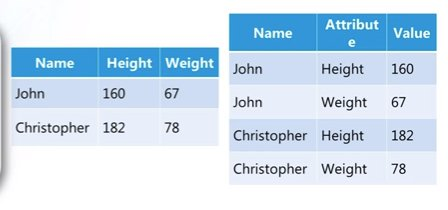

**Wide format** is where we have a single row for every data point with multiple columns to hold the values of various attributes.

**Long format** is where, for each data point we have as many rows as the number of attributes and each row contains the value of a particular attribute for a given data point.

information same represent karna ka tarika different ha 
- long  = rows > coloumns 
- wide = coloumns > rows

In [ ]:
# Q:agar dono data frame same information represent kar raha ha tho dono exist kyu karta ha ?
# kisi particular analysis ka liya long data format tik raha ga or 
# kisi dursa type ka anlysis ka liya ka liya wide
# it depend on the problem statement 
# data kaha sa laya ja raha ha es bhat par bhi depend karta ha 
# agar aap kisi database sa data la kar aa raha ho tho good chance ki wo wide format ho 
# aor data warehouse sa la raho tho tho wo long format ma mila 
# it's depend on your source
# data ko organise karna ka tarika 
# two style ma data represent karna ha benefit and nuksan ha 
# analysis karna ma bhi toda  farak ata ha  

In [ ]:
# as a data analyst scientist apko en dono dataframe ka sath kam karna ana chaya 
# jaraut padna par ek dataframe ko dursa dataframe ma convert kasa kara ya bhi apko ana chaya 
# melt func apka 
# wide data format  ko ---> long  format ma convert karta ha 

# pivot table 
#  long --convert --> wide

# melt 
#  wide --convert --> long

# melt 

In [ ]:
pd.DataFrame({ 'cse':[120]})

,cse
0,120


In [ ]:
pd.DataFrame({ 'cse':[120]}).melt()

,variable,value
0,cse,120


In [ ]:
pd.DataFrame({
    'cse':[120],
    'ece' : [100],
    'mech': [50],
})

,cse,ece,mech
0,120,100,50


In [ ]:
pd.DataFrame({
    'cse':[120],
    'ece' : [100],
    'mech': [50],
}).melt()

,variable,value
0,cse,120
1,ece,100
2,mech,50


### var_name ,value_name
set the name of variable column and value columns

In [ ]:
pd.DataFrame({
    'cse': [120],
    'ece' : [100],
    'mech': [50],
}).melt(var_name='branch',value_name='num_of_students')

,branch,num_of_students
0,cse,120
1,ece,100
2,mech,50


In [ ]:
pd.DataFrame({
    'branch': ['cse','ece','mech'],
    '2020':[100,150,60],
    '2021':[120,130,80],
    '2022':[150,140,70],
})
# deko 2023 ya par ya 2024 ek aor coloumn add kar sakta ha 
# wide format ma ha ek aor coloumn add ho raha ha year ka 

,branch,2020,2021,2022
0,cse,100,120,150
1,ece,150,130,140
2,mech,60,80,70


In [ ]:
pd.DataFrame({
    'branch': ['cse','ece','mech'],
    '2020':[100,150,60],
    '2021':[120,130,80],
    '2022':[150,140,70],
}).melt()

,variable,value
0,branch,cse
1,branch,ece
2,branch,mech
3,2020,100
4,2020,150
5,2020,60
6,2021,120
7,2021,130
8,2021,80
9,2022,150


In [ ]:
# so coloumn row ban gaya e.g branch cse
# baki ka coloumns bhi yahi kar raha ha 
# apko 2020,2021 ,2022 ka bana tha lakin branch ko nahi bana na tha 

### id_var
ya variable convert nahi hoga wide -- to --> long  ma        
    it is still remains same

In [ ]:
pd.DataFrame({
    'branch': ['cse','ece','mech'],
    '2020':[100,150,60],
    '2021':[120,130,80],
    '2022':[150,140,70],
}).melt(id_vars=['branch'],var_name='year',value_name='students')
# id_varska vo usa variable ma convert nahi karaga 
# maltab jab aap wide sa long ma convert karoga
# id var ma jo col hoga vo convert nahi hoga still same 

,branch,year,students
0,cse,2020,100
1,ece,2020,150
2,mech,2020,60
3,cse,2021,120
4,ece,2021,130
5,mech,2021,80
6,cse,2022,150
7,ece,2022,140
8,mech,2022,70


## time_series covid data 

In [ ]:
death = pd.read_csv('time_series_covid19_deaths_global.csv')
death

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,5708,5708,5708,5708,5708,5708,5708,5708,5708,5708
285,NaN,Winter Olympics 2022,39.904200,116.407400,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
286,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,2159,2159,2159,2159,2159,2159,2159,2159,2159,2159
287,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,4019,4019,4022,4022,4023,4023,4024,4024,4024,4024


In [ ]:
confirm = pd.read_csv('time_series_covid19_confirmed_global.csv')
confirm

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
285,NaN,Winter Olympics 2022,39.904200,116.407400,0,0,0,0,0,0,...,535,535,535,535,535,535,535,535,535,535
286,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945
287,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,334021,334021,334066,334108,334196,334294,334425,334425,334629,334661


In [ ]:
# state,country ,latitude,longitude 
# aor us date par kitna death and confirmed cases ha 

In [ ]:
death.shape
# so every country get one row 
# and their are 1081 days 2020 sa lakar 2023 tak ka data yani 3 years ka data ha 
# their are thousand coloumn
# so this data is orginsed in wide format

(289, 1081)

In [ ]:
confirm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1081 entries, Province/State to 1/2/23
dtypes: float64(2), int64(1077), object(2)
memory usage: 2.4+ MB


In [ ]:
confirm.shape

(289, 1081)

In [ ]:
# so both actually same formed
# but in date coloum death -> how many people died
# in confirm -> how many people confirmed cases 

In [ ]:
# so our manager came and say dataset format is different 
# so your task in the format

# country name , date,confirmed, death

In [ ]:
# so first we do melt into long format than merge the dataset 

### melt it 

In [ ]:
death_df = death.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],var_name='date',value_name='death')
# huma en 4 coloumns ko same rakna ha aor baki ko change karna ha 
death_df

,Province/State,Country/Region,Lat,Long,date,death
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,5708
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,0
311250,NaN,Yemen,15.552727,48.516388,1/2/23,2159
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,4024


In [ ]:
confirm_df = confirm.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],var_name='date',value_name='confirm')
confirm_df

,Province/State,Country/Region,Lat,Long,date,confirm
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,703228
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,535
311250,NaN,Yemen,15.552727,48.516388,1/2/23,11945
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,334661


In [ ]:
# now we have to do merge apko ek ya multiple common coloumns chaya
pd.merge(
        left=confirm_df,
        right=death_df,
        on=['Province/State', 'Country/Region', 'Lat', 'Long']
        )


In [ ]:
import pandas as pd 
# I import the dataset 
confirm = pd.read_csv('time_series_covid19_confirmed_global.csv')
death = pd.read_csv('time_series_covid19_deaths_global.csv')
# i melt the dataframe for correct format
death_df = death.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],var_name='date',value_name='death')
confirm_df = confirm.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],var_name='date',value_name='confirm')
# then perform merge 
pd.merge(
        left=confirm_df,
        right=death_df,
        on=['Province/State', 'Country/Region', 'Lat', 'Long']
        )


MemoryError: Unable to allocate 2.50 GiB for an array with shape (335219481,) and data type int64

In [ ]:
import pandas as pd

# Load CSVs
confirm = pd.read_csv('time_series_covid19_confirmed_global.csv', dtype={'Province/State': 'category', 'Country/Region': 'category'})
death = pd.read_csv('time_series_covid19_deaths_global.csv', dtype={'Province/State': 'category', 'Country/Region': 'category'})

# Melt the DataFrame (reduce data types for efficiency)
confirm_df = confirm.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], var_name='date', value_name='confirm')
death_df = death.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], var_name='date', value_name='death')

# Convert 'date' to datetime format (reduces memory)
confirm_df['date'] = pd.to_datetime(confirm_df['date'])
death_df['date'] = pd.to_datetime(death_df['date'])

# Merge while selecting only required columns
merged_df = confirm_df.merge(
    death_df[['Province/State', 'Country/Region', 'Lat', 'Long', 'date', 'death']], 
    on=['Province/State', 'Country/Region', 'Lat', 'Long', 'date'],
    how='inner'
)
# final answer
merged_df[['Country/Region','date','confirm','death']]


C:\Users\sumit\AppData\Local\Temp\ipykernel_14984\1045771331.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  confirm_df['date'] = pd.to_datetime(confirm_df['date'])
C:\Users\sumit\AppData\Local\Temp\ipykernel_14984\1045771331.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  death_df['date'] = pd.to_datetime(death_df['date'])


,Country/Region,date,confirm,death
0,Afghanistan,2020-01-22,0,0
1,Albania,2020-01-22,0,0
2,Algeria,2020-01-22,0,0
3,Andorra,2020-01-22,0,0
4,Angola,2020-01-22,0,0
...,...,...,...,...
311248,West Bank and Gaza,2023-01-02,703228,5708
311249,Winter Olympics 2022,2023-01-02,535,0
311250,Yemen,2023-01-02,11945,2159
311251,Zambia,2023-01-02,334661,4024


In [ ]:
import modin.pandas as pd  # Just replace pandas with modin.pandas

confirm = pd.read_csv('time_series_covid19_confirmed_global.csv')
death = pd.read_csv('time_series_covid19_deaths_global.csv')

confirm_df = confirm.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], var_name='date', value_name='confirm')
death_df = death.melt(id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'], var_name='date', value_name='death')

merged_df = confirm_df.merge(death_df, on=['Province/State', 'Country/Region', 'Lat', 'Long', 'date'], how='inner')

print(merged_df.info())


2025-03-30 16:49:30,889	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-03-30 16:49:58,108	INFO worker.py:1786 -- Started a local Ray instance.
2025-03-30 16:50:10,628	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
import modin.pandas as pd
print(pd.__version__)


0.32.0


# pivot table
power to reshape your dataframe 

In [28]:
import numpy as np 
import pandas as pd
import seaborn as sns

In [29]:
# it is dataset of tips giving in reastuant 
# because pivot table work in categorical variable 
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [32]:
# Question : gender sa hisab sa average total bill 
# approach  to answer is use groupby
df.groupby('sex')['total_bill'].mean()

C:\Users\sumit\AppData\Local\Temp\ipykernel_12796\1336078049.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')['total_bill'].mean()


sex
Male      20.744076
Female    18.056897
Name: total_bill, dtype: float64

In [ ]:
# again Question hum jana na chata ha ki hamri male smoker and non smoker na kitna pay kiya samw with girls 
df.groupby(by=['sex','smoker'],observed=True)[['total_bill']].mean()

total_bill
sex    smoker            
Male   Yes      22.284500
       No       19.791237
Female Yes      17.977879
       No       18.105185

In [33]:
# again Question hum jana na chata ha ki hamri male smoker and non smoker na kitna pay kiya samw with girls 
# we do in correct form 
df.groupby(by=['sex','smoker'],observed=True)[['total_bill']].mean().unstack()

total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [ ]:
# i can extract now the information in two cateogrical variable 
# average bill of smoker male is 22
# this is 3 dim analysis , gender ,smoker(yes or no),average bill 
# ab isi ka shortcut ho jata pivot table

## agg func 

In [ ]:
df.pivot_table(
    index='sex', # rows kon banaga
    columns= 'smoker', # coloumns kon banga
    values='total_bill', # values
    observed=False
)

smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [ ]:
# ya par ek parmater hota ha aggreate function default uski values mean hoti ha aor whai ya hua ha 
# agar aap chaho tho aap koi bhi aggreate function laga sakta ho 

In [ ]:
df.pivot_table(
    index='sex',
    columns='smoker',
    values='total_bill',
    aggfunc='count',
    observed=True
)

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [ ]:
df.pivot_table(
    index='sex',
    columns='smoker',
    values='total_bill',
    aggfunc='std',
    observed=True
)

smoker,Yes,No
sex,,
Male,9.911845,8.726566
Female,9.189751,7.286455


In [ ]:
# or you can built your custom func logic 

In [ ]:
# yadi ma values provide na karu tho ya har coloumn par ka dega 
# lakin merma ma type error aa gaya .
# vo ma cateogrical variable ma mean laga raha hu count use karo 
df.pivot_table(index='sex',columns='smoker',aggfunc='count',observed=True)

day     size     time     tip     total_bill    
smoker Yes  No  Yes  No  Yes  No Yes  No        Yes  No
sex                                                    
Male    60  97   60  97   60  97  60  97         60  97
Female  33  54   33  54   33  54  33  54         33  54

In [ ]:
df.pivot_table(index='sex',columns='smoker',aggfunc='count',observed=True)['size']
# aap ek particular column bhi nikal sakta ha 

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


## multidimensional 

In [ ]:
df.pivot_table(
    index=['sex','smoker'],
    columns=['day','time'],
    values='total_bill',
    observed=True
    
    )

day                 Thur               Fri                Sat        Sun
time               Lunch Dinner      Lunch  Dinner     Dinner     Dinner
sex    smoker                                                           
Male   Yes     19.171000    NaN  11.386667  25.892  21.837778  26.141333
       No      18.486500    NaN        NaN  17.475  19.929063  20.403256
Female Yes     19.218571    NaN  13.260000  12.200  20.266667  16.540000
       No      15.899167  18.78  15.980000  22.750  19.003846  20.824286

In [ ]:
# you can do depth of analysis with it 
# example 
# saturday ko dinner ma non somker males on average 19 dollar pay karta ha 
# this is 5 dim analysis 
# agar apka paas aor cateogrical variable ha aap unko add kar sakta ho 

In [ ]:
df.pivot_table(
    index=['sex','smoker'],
    columns=['day','time'],
    
    observed=True
    
    )

# sabhi coloumns par analysis yar par 3 coloumn size,tip,totol_bills par  

size                                                   tip  \
day                Thur              Fri              Sat       Sun      Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner     Lunch   
sex    smoker                                                                   
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  3.058000   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  2.941500   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  2.990000   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  2.437083   

                                                      total_bill         \
day                    Fri              Sat       Sun       Thur          
time          Dinner Lunch Dinner    Dinner    Dinner      Lunch Dinner   
sex    smoker                                                             
Male   Yes       NaN  1.90  3.246  2.879259  3.521333  19.171000    NaN   
       No        NaN   NaN  2.500  3.256563  3.115349  18.486500    NaN   
Female Yes       NaN  2.66  2.700  2.868667  3.500000  19.218571    NaN   
       No        3.0  3.00  3.250  2.724615  3.329286  15.899167  18.78   

                                                        
day                  Fri                Sat        Sun  
time               Lunch  Dinner     Dinner     Dinner  
sex    smoker                                           
Male   Yes     11.386667  25.892  21.837778  26.141333  
       No            NaN  17.475  19.929063  20.403256  
Female Yes     13.260000  12.200  20.266667  16.540000  
       No      15.980000  22.750  19.003846  20.824286

## diff agg func

In [ ]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [ ]:
# you can also use different aggerate func on coloumns you want 
df.pivot_table(
    index=['sex','smoker'],
    columns=['day','time'],
    aggfunc={'size':'mean','tip':'max','total_bill':'sum'},
    observed=True
    
    )

size                                               tip  \
day                Thur              Fri              Sat       Sun  Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner Lunch   
sex    smoker                                                               
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  5.00   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  6.70   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  5.00   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  5.17   

                                                total_bill                \
day                    Fri           Sat    Sun       Thur           Fri   
time          Dinner Lunch Dinner Dinner Dinner      Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       NaN  2.20   4.73  10.00    6.5     191.71    NaN  34.16   
       No        NaN   NaN   3.50   9.00    6.0     369.73    NaN    NaN   
Female Yes       NaN  3.48   4.30   6.50    4.0     134.53    NaN  39.78   
       No        3.0  3.00   3.25   4.67    5.2     381.58  18.78  15.98   

                                       
day                       Sat     Sun  
time           Dinner  Dinner  Dinner  
sex    smoker                          
Male   Yes     129.46  589.62  392.12  
       No       34.95  637.73  877.34  
Female Yes      48.80  304.00   66.16  
       No       22.75  247.05  291.54

## margins 

In [ ]:
df.pivot_table(
    index='sex',
    columns='smoker',
    values='total_bill',
    aggfunc='sum',
    margins=True,
    observed=True
)
# margines it is a hidden parameter
# which provide the sum of rows and coloums 

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [ ]:
# analysis 
# total males and female na kitna bill paya kar
# totoal smoker and non smoker na kitna bill pay kiya 

In [ ]:
# you can also use different aggerate func on coloumns you want 
df.pivot_table(
    index=['sex','smoker'],
    columns=['day','time'],
    aggfunc={'size':'mean','tip':'max','total_bill':'sum'},
    margins= True,
    observed=True
    
    )

size                                                 \
day                Thur              Fri                 Sat       Sun   
time              Lunch Dinner     Lunch    Dinner    Dinner    Dinner   
sex    smoker                                                            
Male   Yes     2.300000    NaN  1.666667  2.400000  2.629630  2.600000   
       No      2.500000    NaN       NaN  2.000000  2.656250  2.883721   
Female Yes     2.428571    NaN  2.000000  2.000000  2.200000  2.500000   
       No      2.500000    2.0  3.000000  2.000000  2.307692  3.071429   
All            2.459016    2.0  2.000000  2.166667  2.517241  2.842105   

                          tip               ...                      \
day                 All  Thur          Fri  ...    Sat    Sun   All   
time                    Lunch Dinner Lunch  ... Dinner Dinner         
sex    smoker                               ...                       
Male   Yes     2.500000  5.00    NaN  2.20  ...  10.00    6.5  10.0   
       No      2.711340  6.70    NaN   NaN  ...   9.00    6.0   9.0   
Female Yes     2.242424  5.00    NaN  3.48  ...   6.50    4.0   6.5   
       No      2.592593  5.17    3.0  3.00  ...   4.67    5.2   5.2   
All            2.569672  6.70    3.0  3.48  ...  10.00    6.5  10.0   

              total_bill                                                   
day                 Thur           Fri              Sat      Sun      All  
time               Lunch Dinner  Lunch  Dinner   Dinner   Dinner           
sex    smoker                                                              
Male   Yes        191.71    NaN  34.16  129.46   589.62   392.12  1337.07  
       No         369.73    NaN    NaN   34.95   637.73   877.34  1919.75  
Female Yes        134.53    NaN  39.78   48.80   304.00    66.16   593.27  
       No         381.58  18.78  15.98   22.75   247.05   291.54   977.68  
All              1077.55  18.78  89.92  235.96  1778.40  1627.16  4827.77  

[5 rows x 21 columns]

# plotting graph 

In [ ]:
expense_df = pd.read_csv('expense_data.csv')
expense_df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0
...,...,...,...,...,...,...,...,...,...,...,...
272,11/22/2021 14:16,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0
273,11/22/2021 14:16,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0
274,11/21/2021 17:07,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0
275,11/21/2021 15:50,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0


In [ ]:
# Task month by month har cateogory ma kitna karcha hua 
expense_df['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [ ]:
# task date coloumn ma sa har month ko extract karo
expense_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [ ]:
# so your date col is string usko date ma convert karo
expense_df['Date']= pd.to_datetime(expense_df['Date'])

In [ ]:
expense_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [ ]:
expense_df['Date'].dt.month_name()
# now create a new month coloumn 

0         March
1         March
2         March
3         March
4         March
         ...   
272    November
273    November
274    November
275    November
276    November
Name: Date, Length: 277, dtype: object

In [ ]:
expense_df['month']= expense_df['Date'].dt.month_name()

In [ ]:
expense_df.columns

Index(['Date', 'Account', 'Category', 'Subcategory', 'Note', 'INR',
       'Income/Expense', 'Note.1', 'Amount', 'Currency', 'Account.1', 'month'],
      dtype='object')

In [ ]:
expense_df.head()
# har gharca ka aga konsa month ma kaharcha hua 

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


In [ ]:
expense_df.columns

Index(['Date', 'Account', 'Category', 'Subcategory', 'Note', 'INR',
       'Income/Expense', 'Note.1', 'Amount', 'Currency', 'Account.1'],
      dtype='object')

In [ ]:
expense_df.pivot_table(
    index='month',
    columns='Category',
    values='INR',
    aggfunc='sum',
    fill_value=0
)
# missing value matlab us month ma us cateogry ma koi garcha nahi hua
# we can fill the missing values by fill_value parameter 0 

Category,Allowance,Apparel,Beauty,Education,Food,Gift,Household,Other,Petty cash,Salary,Self-development,Social Life,Transportation
month,,,,,,,,,,,,,
December,11000.0,2590.0,196.0,0.0,6440.72,0.0,4800.0,1790.0,0.0,0.0,400.0,513.72,914.0
February,0.0,798.0,0.0,0.0,5579.85,0.0,2808.0,20000.0,0.0,0.0,0.0,1800.00,5078.8
January,1000.0,0.0,0.0,1400.0,9112.51,0.0,4580.0,13178.0,0.0,8000.0,0.0,200.00,2850.0
March,0.0,0.0,0.0,0.0,195.00,0.0,0.0,900.0,0.0,0.0,0.0,0.00,30.0
November,2000.0,0.0,0.0,0.0,3174.40,115.0,0.0,2000.0,3.0,0.0,0.0,0.00,331.0


### each cateogroy expenses 

<Axes: xlabel='month'>

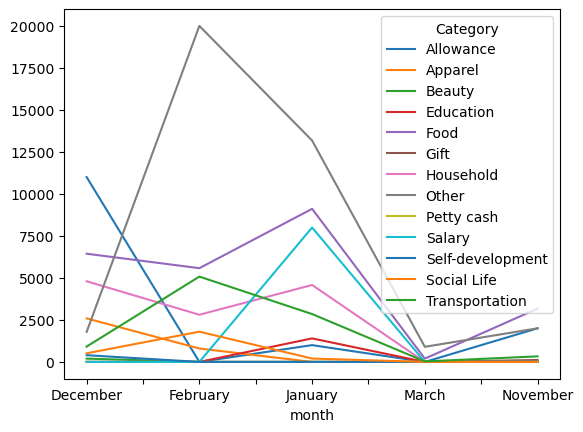

In [ ]:
expense_df.pivot_table(
    index='month',
    columns='Category',
    values='INR',
    aggfunc='sum',
    fill_value=0
).plot()

### income and expenses chart

<Axes: xlabel='month'>

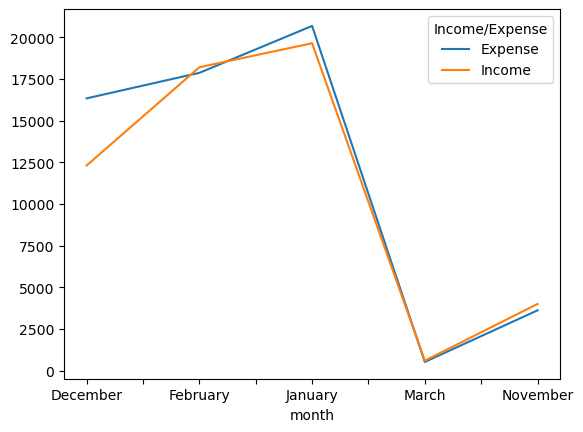

In [ ]:
expense_df.pivot_table(
    index='month',
    columns='Income/Expense',
    values='INR',
    aggfunc='sum',
    fill_value=0
).plot()

In [ ]:
# chart ko dek kar hum nikal sakta ha ki 
# person jitna income kamta ha utna expenses(kharcha) ma uda deta ha 

### cash vs online kharcha 

<Axes: xlabel='month'>

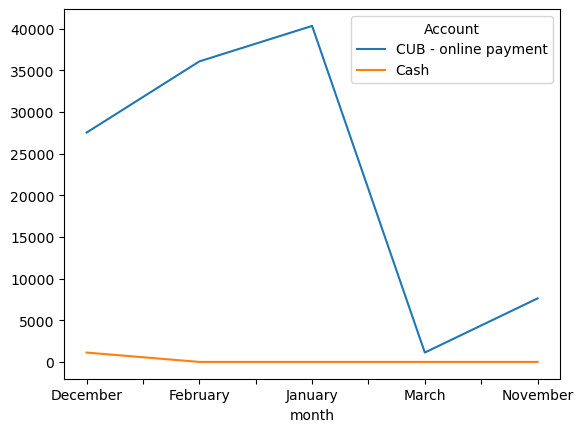

In [ ]:
expense_df.pivot_table(
    index='month',
    columns='Account',
    values='INR',
    aggfunc='sum',
    fill_value=0
).plot()

In [ ]:
# so online jada kharcha kiya and cash ma kam ha 

In [ ]:
# this is the best part about pivot_table 
# jasa catogries ka upar koi bhi aggreate function use karka usko plot kar sakta ha
# 